# 02. Club analysis

**Questions:**
1. Without xG, is shots-on-target difference a reasonable stand-in for how well a club is playing?
2. Does first-phase form tell us anything about how a club does in the knockouts?
3. How sensitive is the Tournament Performance Index to the weights we picked?

In [1]:
import sys
from pathlib import Path

# Let the notebook import from src/ when it's run from the notebooks folder.
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.database.connection import read_sql

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "axes.edgecolor": "#c3c2b7",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left", "font.size": 10,
    "axes.prop_cycle": plt.cycler(color=["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]),
})
BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#c3c2b7"

In [2]:
from scipy import stats

from src.analysis.tournament_index import DEFAULT_WEIGHTS, index_components, tournament_index

matches = read_sql("SELECT * FROM v_club_matches")
matches["goal_diff"] = matches["goals_for"] - matches["goals_against"]
matches["sot_diff"] = matches["shots_on_target"] - matches["shots_on_target_against"]
first_phase = matches[matches["stage"].isin(["group_stage", "league_phase"])]
knockouts = matches[~matches["stage"].isin(["group_stage", "league_phase"])]

## 1. Shots-on-target difference against goal difference

Each point is one club in one season's first phase (groups or league phase).

492 club-seasons. Each extra shot on target per match is worth about 0.40 goals of difference.


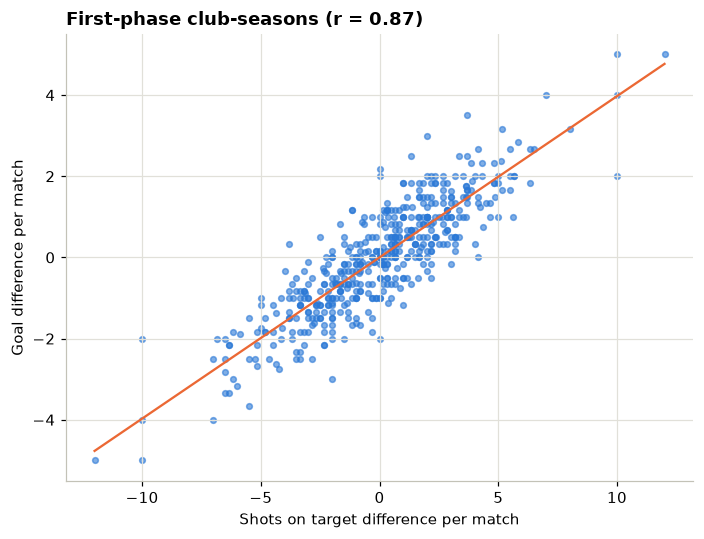

In [3]:
per_club = first_phase.groupby(["season_year", "club_id"]).agg(
    goal_diff=("goal_diff", "mean"), sot_diff=("sot_diff", "mean"), points=("points", "mean")
).reset_index()

r = per_club[["goal_diff", "sot_diff"]].corr().iloc[0, 1]
slope, intercept = np.polyfit(per_club["sot_diff"], per_club["goal_diff"], 1)

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(per_club["sot_diff"], per_club["goal_diff"], s=14, alpha=0.6, color=BLUE)
line = np.linspace(per_club["sot_diff"].min(), per_club["sot_diff"].max(), 10)
ax.plot(line, slope * line + intercept, color=ORANGE)
ax.set(title=f"First-phase club-seasons (r = {r:.2f})", xlabel="Shots on target difference per match",
       ylabel="Goal difference per match")
plt.tight_layout()
print(f"{len(per_club)} club-seasons. Each extra shot on target per match is worth about {slope:.2f} goals of difference.")

Strong relationship: r is about 0.87. Clubs that out-shoot their opponents on target nearly always have a
better goal difference, and each extra shot on target per match is worth about 0.4 goals of difference.

## 2. Does the first phase predict the knockouts?

Take clubs that played at least two knockout games, and compare their first-phase numbers with their
goal difference per match in the knockouts.

In [4]:
knockout_form = knockouts.groupby(["season_year", "club_id"]).agg(
    knockout_goal_diff=("goal_diff", "mean"), knockout_games=("goal_diff", "size")
).reset_index()
paired = per_club.merge(knockout_form, on=["season_year", "club_id"])
paired = paired[paired["knockout_games"] >= 2]

rows = []
for column, label in [("points", "Points per match"), ("goal_diff", "Goal difference per match"),
                      ("sot_diff", "Shots on target difference per match")]:
    r, p = stats.pearsonr(paired[column], paired["knockout_goal_diff"])
    rows.append({"first-phase measure": label, "r with knockout goal diff": round(r, 3), "p-value": p})
print(f"{len(paired)} club-seasons with two or more knockout games")
pd.DataFrame(rows)

240 club-seasons with two or more knockout games


,first-phase measure,r with knockout goal diff,p-value
0,Points per match,0.352,2.030785e-08
1,Goal difference per match,0.381,1.047762e-09
2,Shots on target difference per match,0.361,8.510844e-09


All three carry some signal (r around 0.35 to 0.38, clearly not zero with 240 club-seasons), but none is
dramatically better than the others. Shots-on-target difference is **not** a better predictor than plain
goal difference here, which is worth saying because the dashboard leans on it as the "xG stand-in".

The honest summary: shots-on-target difference is useful because it's steadier and says something about
*how* a club got its results, not because it predicts the future better. Knockouts are also against
stronger opponents, which pulls everyone's numbers down and weakens any correlation.

## 3. How much do the index weights matter?

Compare the default Tournament Performance Index with an equal-weight version for every finished season.
If the rankings barely move, the exact weights aren't doing much work.

In [5]:
seasons = read_sql("SELECT start_year FROM seasons WHERE start_year < 2026")["start_year"]
components = index_components(matches[matches["season_year"].isin(seasons)], finished_seasons=set(seasons))

default = tournament_index(components)
equal = tournament_index(components, {name: 1 / len(DEFAULT_WEIGHTS) for name in DEFAULT_WEIGHTS})
both = default.merge(equal[["season_year", "club_id", "tpi_rank"]], on=["season_year", "club_id"],
                     suffixes=("", "_equal"))

by_season = both.groupby("season_year").apply(
    lambda df: stats.spearmanr(df["tpi_rank"], df["tpi_rank_equal"])[0], include_groups=False
)
print(f"Spearman rank correlation, default vs equal weights: median {by_season.median():.3f}, "
      f"lowest {by_season.min():.3f}")
moves = (both["tpi_rank"] - both["tpi_rank_equal"]).abs()
print(f"Median change in rank: {moves.median():.0f} places; 90th percentile: {moves.quantile(0.9):.0f} places")

Spearman rank correlation, default vs equal weights: median 0.990, lowest 0.974
Median change in rank: 1 places; 90th percentile: 2 places


In [6]:
names = read_sql("SELECT club_id, name FROM clubs")
latest = default[default["season_year"] == 2025].merge(names, on="club_id").head(10)
latest[["tpi_rank", "name", "tpi", "points_per_match", "goal_diff_per_match", "sot_diff_per_match",
        "opponent_strength", "progression"]].round(2)

,tpi_rank,name,tpi,points_per_match,goal_diff_per_match,sot_diff_per_match,opponent_strength,progression
0,1.0,Paris Saint-Germain,1.76,2.06,1.29,2.94,1575.35,7.0
1,2.0,Bayern Munich,1.74,2.43,1.64,3.14,1557.94,5.0
2,3.0,Arsenal,1.68,2.47,1.53,2.93,1526.25,6.0
3,4.0,Barcelona,1.06,1.92,1.00,2.83,1498.08,4.0
4,5.0,Liverpool,1.06,1.75,0.92,4.08,1534.42,4.0
5,6.0,Real Madrid,0.85,1.93,0.93,0.36,1513.96,4.0
6,7.0,Tottenham Hotspur,0.82,2.00,0.80,1.20,1479.38,3.0
7,8.0,Sporting CP,0.73,1.67,0.58,0.92,1544.01,4.0
8,9.0,Newcastle United,0.67,1.75,0.92,1.33,1495.49,3.0
9,10.0,Manchester City,0.59,1.60,0.20,3.30,1507.31,3.0


The rankings are very stable to the weights: the rank correlation between default and equal weights stays
high in every season, and most clubs move only a place or two. That's reassuring, because the weights are
a judgement call. It also means the index mostly agrees with simpler measures like points and goal
difference, and its main value is putting them side by side.

## Conclusion

- Shots-on-target difference tracks goal difference closely (r about 0.87), so it's a fair descriptive
  stand-in for xG difference, as long as we remember it ignores shot quality.
- It doesn't predict knockout form better than goal difference does. First-phase numbers only explain a
  modest part of knockout results.
- The Tournament Performance Index isn't very sensitive to its weights, which makes it safer to show, but it
  shouldn't be sold as revealing anything the underlying components don't.